# Two Steps MultiFidelity Neural Network

Code to show the performance of the Neural Network when dealing with different LF datasets 

In [1]:
######### LIBRARIES ############
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
from keras.models import save_model
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from Multifidelity_support import getModel, kCrossVal, transfBestparam, import_data, normalization, add_noise, MultiFidelity
from time import perf_counter
import pandas
import pickle
import os
import keras
import tensorflow as tf


In [2]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

## Data Preparation

In [3]:
# import of the discretization and diffusion parameter values
Discretizations= np.loadtxt(
    "../DATA/Discretizations.txt"
).astype(
    int
)[::-1]

diffusion= np.loadtxt(
    "../DATA/diffusion.txt"
).astype(
    int
)

In [4]:
# introduction of the high fidelity part of the dataset
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

# I consider only the reaction term as a variable
U_HF_test = U_HF_test[:, -1, 44,44]
# normalization of the data
reaction_HF_test = normalization(reaction_HF_test)
U_HF_test=normalization(U_HF_test)

# transformation of the dataseet
reaction_HF_test_original=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]
U_HF_test_original=U_HF_test

In [5]:
# data augmentation introducing a noise
noise_stddev1=[0.01,0.005,0.02,0.005]
noise_stddev2=[0.005,0.003,0.01,0.003]

(U_HF_test,reaction_HF_test)=add_noise(noise_stddev1,noise_stddev2,reaction_HF_test,U_HF_test)
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

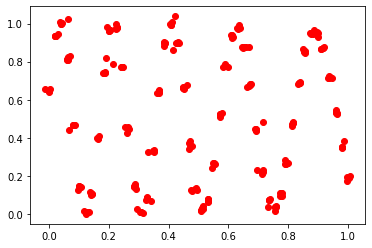

In [6]:
# plot of the new dataset
plt.plot(reaction_HF_test[:,0], U_HF_test, "ro", linewidth=1, label="HF model with noise")
plt.show()

In [7]:
#print(reaction_HF_test.shape)
#print(U_HF_test.shape)

# Number of data of High and Low Fidelity components of the dataset
n_HF = np.array([100])
Nlf = np.array([200])

batch_size=[200,100]


In [8]:
U_LF_list = []
U_HF_list = []
# number of epochs 
Nepo=[7000,8000]

# NepoLF = 7000  # number of epochs for first NN: NN_LF
# NepoHF = 8000  # number of epochs for second NN: NN_HF

r2_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores HF R^2
r2_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','R2'])  # dataframe which stores LF R^2
mse_HF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores HF MSE
mse_LF_df = pandas.DataFrame(columns=['Discretization','diffusion','MSE'])  # dataframe which stores LF MSE



## Neural Network
Cycle on the Discretization and the value of the diffusion 

In [9]:
##############################àTEST#############################


# for m in range(len(Discretizations)):
#     for d in range(len(diffusion)):
#         for nhf in n_HF:
#             for nlf in Nlf:
#                 permutation = np.random.permutation(len(reaction_HF_test))
#                 ### IMPORT LF DATASETs
#                 file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
#                 (reaction_LF_test, U_LF_test) = import_data(file_path_LF)
#                 reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
#                 U_HF = U_HF_test[permutation][0:nhf]
#                 #print(nhf)

                
#                 reaction_LF_test = normalization(reaction_LF_test)
#                 U_LF_test = U_LF_test[
#                 :,
#                 - 1,
#                 int(4*(Discretizations[m]-1)/9),
#                 int(4*(Discretizations[m]-1)/9)
#                 ]        
#                 U_LF_test = normalization(U_LF_test)
                
#                 reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
#                 U_LF_test_original=U_LF_test
                
#                 # NOISE
#                 noise_std1=[0.02,0.01,0.02,0.01]
#                 noise_std2=[0.01,0.005,0.01,0.005]

#                 (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)

                
#                 # noise_stddev2 = 0.02       # value?
#                 # noise2 = np.random.normal(0, noise_stddev2, U_LF_test.shape)
#                 # noise_stddev3 = 0.01       # value?
#                 # noise3 = np.random.normal(0, noise_stddev3, U_LF_test.shape)
#                 # U_LF_noise2 = U_LF_test + noise2
#                 # U_LF_noise3 = U_LF_test + noise3
#                 # noise_stddev4 = 0.02       # value?
#                 # noise4 = np.random.normal(0, noise_stddev4, U_LF_test.shape)
#                 # noise_stddev5 = 0.01       # value?
#                 # noise5 = np.random.normal(0, noise_stddev5, U_LF_test.shape)
#                 # U_LF_noise4 = U_LF_test + noise4
#                 # U_LF_noise5 = U_LF_test + noise5
#                 # noise_stddev6 = 0.02       # value?
#                 # noise6 = np.random.normal(0, noise_stddev6, U_LF_test.shape)
#                 # U_LF_noise6 = U_LF_test + noise6
#                 # noise_stddev7 = 0.01       # value?
#                 # noise7 = np.random.normal(0, noise_stddev7, U_LF_test.shape)
#                 # U_LF_noise7 = U_LF_test + noise7

#                 # U_LF_test = np.concatenate((U_LF_test, U_LF_noise2,U_LF_noise3,U_LF_noise4,U_LF_noise5,U_LF_noise6,U_LF_noise7),axis=0)

#                 # noise_stddev2 = 0.01       # value?
#                 # noise2 = np.random.normal(0, noise_stddev2, reaction_LF_test.shape)
#                 # noise_stddev3 = 0.005       # value?
#                 # noise3 = np.random.normal(0, noise_stddev3, reaction_LF_test.shape)
#                 # reaction_LF_noise2 = reaction_LF_test + noise2
#                 # reaction_LF_noise3 = reaction_LF_test + noise3
#                 # noise_stddev4 = 0.01       # value?
#                 # noise4 = np.random.normal(0, noise_stddev4, reaction_LF_test.shape)
#                 # noise_stddev5 = 0.005       # value?
#                 # noise5 = np.random.normal(0, noise_stddev5, reaction_LF_test.shape)
#                 # reaction_LF_noise4 = reaction_LF_test + noise4
#                 # reaction_LF_noise5 = reaction_LF_test + noise5
#                 # noise_stddev6 = 0.005       # value?
#                 # noise6 = np.random.normal(0, noise_stddev6, reaction_LF_test.shape)
#                 # reaction_LF_noise6 = reaction_LF_test + noise6
#                 # noise_stddev7 = 0.01       # value?
#                 # noise7 = np.random.normal(0, noise_stddev7, reaction_LF_test.shape)
#                 # reaction_LF_noise7 = reaction_LF_test + noise7

#                 # reaction_LF_test = np.concatenate((reaction_LF_test, reaction_LF_noise2,reaction_LF_noise3,reaction_LF_noise4,reaction_LF_noise5,reaction_LF_noise6,reaction_LF_noise7))
                
                
#                 # randomization
#                 permutation = np.random.permutation(len(reaction_LF_test))
#                 reaction_LF = reaction_LF_test[permutation][0:nlf]
#                 U_train_LF = U_LF_test[permutation][0:nlf]

#                 reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
#                 reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                
                
#                 print(
#                 f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
#                 )
                
#                 print(
#                 f"********************  # Diff: = {diffusion[d]}  ********************"
#                 )
                
#                 print(
#                 f"********************  # NHF: = {nhf}  ********************"
#                 )
#                 print(
#                 f"********************  # NLF: = {nlf}  ********************"
#                 )

#                 test_mse_HF_list = []
#                 test_mse_LF_list = []

#                 r2_HF_list = []
#                 r2_LF_list = []
                
#                 ##########################       FIRST NN: NN_LF     ##########################
#                 K.clear_session()
#                 bestLF_params = {
#                     "lr": 0.0255,
#                     "kernel_init": "glorot_uniform",
#                     "opt": "Adam",
#                 } 
#                 best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

#                 # reproducibilty porpuse 
#                 learning_rate = bestLF_params["lr"]
#                 optimizer_type = bestLF_params["opt"]

#                 # Fissa i parametri di ottimizzazione
#                 if optimizer_type == "Adam":
#                     optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
#                 elif optimizer_type == "Nadam":
#                     optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
#                 elif optimizer_type == "Adamax":
#                     optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
#                 else:
#                     raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
#                 #
#                 names=["LF","2step"]
#                 params=[bestLF_params, best_params]
#                 model= MultiFidelity(names,params=params,data_train_LF=reaction_LF,output_train_LF=U_train_LF,data_train_HF=reaction_HF, output_train_HF=U_HF,N=Nepo,n=batch_size,do_HPO=False,verbose=False)
#                 #model.model_list[0]
                
#                 # modelLF = getModel(bestLF_params, "LF")  # ann_functions
#                 # histLF = modelLF.fit(
#                 #     reaction_LF, U_train_LF,epochs=NepoLF, batch_size=nlf, verbose=0)
                
                
                
#                 # plt.plot(modelLF.history.history['loss'][100:], label='Training Loss')
#                 # plt.title('Mean Squared Error (MSE) over Epochs')
#                 # plt.xlabel('Epochs')
#                 # plt.ylabel('MSE')
#                 # plt.legend()
#                 # plt.show()

#                 ULF = model.model_list[0].prediction(reaction_LF_test_original)

#                 # U_LF_list.append(ULF)
#                 # print("\nLF Model:")
#                 print("low fidelity NN")
#                 (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
#                 test_mse_LF_list.append(test_mse_LF)
#                 #print(f"Test MSE: {test_mse_LF}")

#                 # r_2 = 1 - np.sum(np.square(U_LF_test_original - ULF[:, 0])) / np.sum(
#                 #     np.square(U_LF_test_original - np.mean(U_LF_test_original))
#                 # )
#                 r2_LF_list.append(r2_LF)
#                 #print(f"R^2: {r2_LF}")
                
#                 # start = perf_counter()
#                 # reaction_test_help = modelLF.predict(reaction_HF_test)[:, 0]
#                 # reaction_test_in = np.concatenate(
#                 #     (reaction_HF_test, reaction_test_help.reshape(-1,1)),axis=1
#                 # )  # <- TEST INPUT for the second NN: NN_HF

                
#                 # reaction_test_help_original = modelLF.predict(reaction_HF_test_original)[:, 0]
#                 # reaction_test_in_original = np.concatenate(
#                 #     (reaction_HF_test_original, reaction_test_help_original.reshape(-1,1)),axis=1
#                 # )
                
                
#                 # reaction_train_help = modelLF.predict(reaction_HF)[
#                 #     :, 0
#                 # ]  # f_LF(mu_hf_train)
#                 input_HF = np.concatenate(
#                     (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
#                 )  # <- TRAINING INPUT for the second NN: NN_HF

#                 input_HF_train = np.concatenate(
#                     (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
#                 ) 
#                 # name = "2step"
#                 # K.clear_session()
#                 # best parameters obtained by HPO:

#                 # best_params = {
#                 #     "kernel_init": "uniform",
#                 #     "l2weight": 0.0002588943618918075,
#                 #     "lr": 0.008365144388542751,
#                 #     "nodes": 16.0,
#                 #     "opt": "Adam",
#                 # }
#    #             best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}
                
#                 # # reproducibilty porpuse 
#                 # learning_rate = best_params["lr"]
#                 # optimizer_type = best_params["opt"]

#                 # # Fissa i parametri di ottimizzazione
#                 # if optimizer_type == "Adam":
#                 #     optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
#                 # elif optimizer_type == "Nadam":
#                 #     optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
#                 # elif optimizer_type == "Adamax":
#                 #     optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
#                 # else:
#                 #     raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
#                 # #
                
                
                
#                 # finalModel = getModel(
#                 #     best_params, name
#                 # )  # final model chosen according to the best paramters
#                 # hist = finalModel.fit(
#                 #     reaction_final,
#                 #     U_HF,
#                 #     validation_data=(reaction_test_in_original, U_HF_test_original),
#                 #     epochs=NepoHF,
#                 #     batch_size=nhf,
#                 #     verbose=0,
#                 #     validation_freq=20,
#                 # )
            
#                 # plt.plot(model.model_list[1].history.history['loss'][100:], label='Training Loss')
#                 # #plt.plot(finalModel.history.history['loss'][50:], label='Training Loss')
#                 # plt.title('Mean Squared Error (MSE) over Epochs (final Model)')
#                 # plt.xlabel('Epochs')
#                 # plt.ylabel('MSE')
#                 # plt.legend()
#                 # plt.show()

#                 # UHF = finalModel.predict(reaction_test_in_original)
#                 # U_HF_list.append(UHF)

#                 # stop = perf_counter()
#                 # elapsed = stop - start
#                 # print("Elapsed time: ", elapsed)
#                 # print("\nHF Model:")
#                 print("Final model")
#                 (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original)

                
#                 test_mse_HF_list.append(test_mse_HF)
#                 #print(f"Test MSE: {test_mse_HF}")

#                 # r2_HF = 1 - np.sum(np.square(U_HF_test_original - UHF[:, 0])) / np.sum(
#                 #     np.square(U_HF_test_original - np.mean(U_HF_test_original))
#                 # )
#                 r2_HF_list.append(r2_HF)
#                 #print(f"R^2: {r2_HF}")
                
                
#                 plt.figure()
#                 plt.plot(
#                 reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
#                 )
#                 plt.plot(
#                 reaction_LF[:, 0],
#                 U_train_LF,
#                 "yo",
#                 markersize=5,
#                 label="LF training points",
#                 )
#                 plt.plot(
#                 reaction_LF_test[:, 0],
#                 model.model_list[0].prediction(reaction_LF_test),
#                 "g-",
#                 linewidth=3,
#                 label="Predicted LF model",
#                 )
#                 plt.legend(prop={"size": 8.3})
#                 plt.show()
                
#                 plt.figure()
#                 plt.plot(
#                 reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model"
#                 )
#                 plt.plot(
#                 input_HF_train[:, 0],
#                 U_HF,
#                 "ro",
#                 markersize=5,
#                 label="HF training points",
#                 )
                
                
#                 order=np.argsort(reaction_LF[:,0])
                
#                 plt.plot(
#                 reaction_LF[order,0],
#                 U_train_LF[order],
#                 "y-",
#                 markersize=5,
#                 label="LF training points",
#                 )
#                 plt.plot(
#                 input_HF[:, 0],
#                 model.model_list[1].prediction(input_HF),
#                 "g-",
#                 linewidth=3,
#                 label="Predicted HF model",
#                 )
#                 plt.legend(prop={"size": 8.3})
#                 plt.show()

#                 #r2_LF_df[[str(Discretizations[m]),diffusion[d]]] = r2_LF_list
#                 #r2_HF_df[[str(Discretizations[m]),diffusion[d]]] = r2_HF_list
#                 #mse_LF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_LF_list
#                 #mse_HF_df[[str(Discretizations[m]),diffusion[d]]] = test_mse_HF_list
                
                
#                 new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
#                 r2_LF_df = r2_LF_df.append(new, ignore_index=True)      
#                 new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
#                 r2_HF_df = r2_HF_df.append(new, ignore_index=True)  
#                 new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
#                 mse_LF_df = mse_LF_df.append(new, ignore_index=True) 
#                 new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
#                 mse_HF_df = mse_HF_df.append(new, ignore_index=True)
                
#                 # if len(r2_HF_list[:-1])>0 and r2_HF_list[-1]<max(r2_HF_list[:-1]):
#                 # #     save_model(finalModel,"finalModel2NN.h5")
                
                
#                 ##  SALVATAGGIO CON NUOVA CLASSE?
#                 print(r2_HF_list)
#                 if not r2_HF_list[:-1]:
#                     model.save()
#                 elif r2_HF_list[:-1] and r2_HF_list[-1] > max(r2_HF_list[:-1]) and test_mse_HF_list[-1]<min(test_mse_HF_list[:-1]):
#                     model.save()
        
# print(r2_HF_df.round(5))
# print(mse_HF_df.round(5))



********************  # Nb. nodes = 46  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************


The function training took 73.74589037895203 seconds.


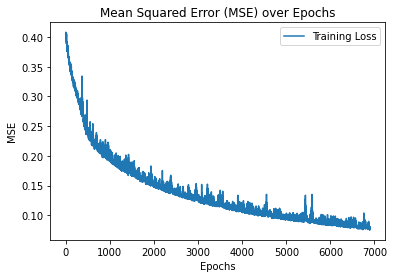

[170, 75, 102, 124, 117, 40, 52, 151, 8, 103, 130, 153, 190, 60, 150, 199, 144, 142, 2, 42, 4, 39, 78, 129, 144, 78, 12, 87, 97, 181, 40, 120, 17, 84, 16, 0, 167, 119, 180, 187, 106, 35, 114, 138, 97, 10, 12, 109, 75, 87, 173, 147, 15, 32, 197, 109, 4, 198, 8, 131, 147, 26, 63, 61, 122, 157, 72, 46, 131, 136, 114, 25, 61, 64, 136, 158, 42, 1, 64, 116, 55, 197, 147, 96, 32, 26, 64, 42, 94, 75, 177, 40, 43, 5, 76, 12, 125, 55, 102, 156]
The function training took 33.64355111122131 seconds.


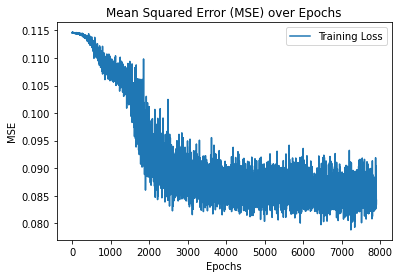

[170, 75, 102, 124, 117, 40, 52, 151, 8, 103, 130, 153, 190, 60, 150, 199, 144, 142, 2, 42, 4, 39, 78, 129, 144, 78, 12, 87, 97, 181, 40, 120, 17, 84, 16, 0, 167, 119, 180, 187, 106, 35, 114, 138, 97, 10, 12, 109, 75, 87, 173, 147, 15, 32, 197, 109, 4, 198, 8, 131, 147, 26, 63, 61, 122, 157, 72, 46, 131, 136, 114, 25, 61, 64, 136, 158, 42, 1, 64, 116, 55, 197, 147, 96, 32, 26, 64, 42, 94, 75, 177, 40, 43, 5, 76, 12, 125, 55, 102, 156]
low fidelity NN
Test MSE: 0.005716675882208137
R^2: 0.9541132118663166
Final model
Test MSE: 0.08872472233738411
R^2: 0.21620430136543445


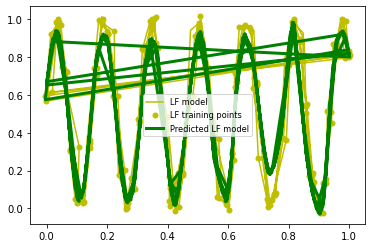

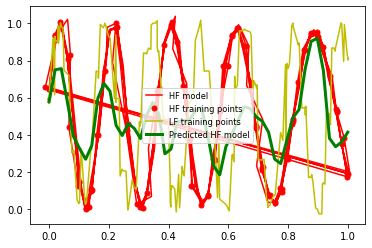

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

Saving ...
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 40.68897891044617 seconds.


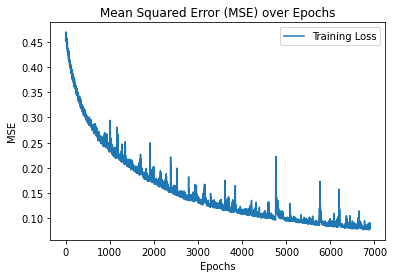

[124, 74, 41, 23, 26, 32, 188, 103, 86, 7, 179, 143, 58, 167, 35, 8, 87, 141, 113, 196, 5, 146, 5, 162, 82, 32, 43, 34, 17, 96, 124, 1, 92, 116, 101, 184, 136, 131, 9, 151, 161, 8, 64, 24, 137, 177, 195, 94, 102, 102, 151, 142, 18, 114, 140, 120, 5, 84, 64, 54, 33, 108, 152, 18, 183, 24, 101, 127, 115, 165, 74, 160, 9, 66, 153, 97, 54, 80, 127, 35, 101, 30, 68, 119, 102, 106, 7, 9, 161, 28, 48, 142, 24, 153, 96, 143, 36, 8, 11, 161]
The function training took 33.84694051742554 seconds.


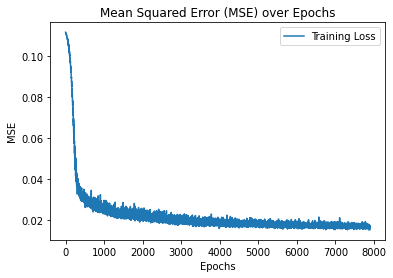

[124, 74, 41, 23, 26, 32, 188, 103, 86, 7, 179, 143, 58, 167, 35, 8, 87, 141, 113, 196, 5, 146, 5, 162, 82, 32, 43, 34, 17, 96, 124, 1, 92, 116, 101, 184, 136, 131, 9, 151, 161, 8, 64, 24, 137, 177, 195, 94, 102, 102, 151, 142, 18, 114, 140, 120, 5, 84, 64, 54, 33, 108, 152, 18, 183, 24, 101, 127, 115, 165, 74, 160, 9, 66, 153, 97, 54, 80, 127, 35, 101, 30, 68, 119, 102, 106, 7, 9, 161, 28, 48, 142, 24, 153, 96, 143, 36, 8, 11, 161]
low fidelity NN
Test MSE: 0.008837373249297063
R^2: 0.9223167438208997
Final model
Test MSE: 0.018865276680608726
R^2: 0.8333438265426749


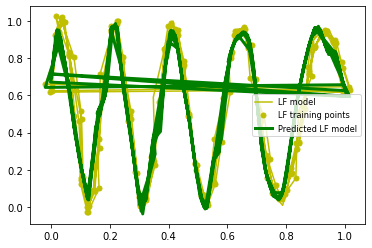

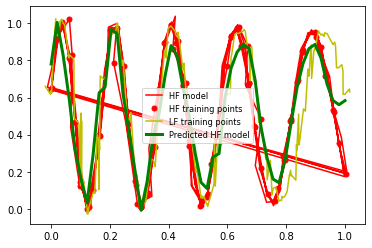

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

********************  # Nb. nodes = 46  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 41.07760715484619 seconds.


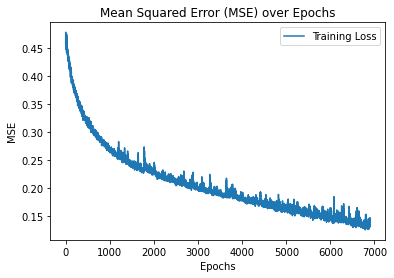

[2, 59, 40, 32, 93, 150, 14, 22, 112, 52, 117, 36, 161, 171, 92, 187, 129, 103, 161, 98, 117, 116, 165, 181, 197, 75, 66, 34, 36, 104, 188, 181, 97, 128, 78, 13, 118, 17, 89, 59, 146, 79, 95, 155, 193, 199, 111, 130, 116, 135, 179, 22, 73, 62, 7, 62, 62, 146, 185, 197, 101, 197, 125, 30, 37, 37, 108, 78, 89, 12, 41, 17, 98, 17, 12, 110, 161, 169, 42, 124, 174, 181, 37, 115, 180, 112, 1, 18, 24, 19, 117, 112, 121, 151, 79, 35, 104, 59, 169, 74]
The function training took 41.674628496170044 seconds.


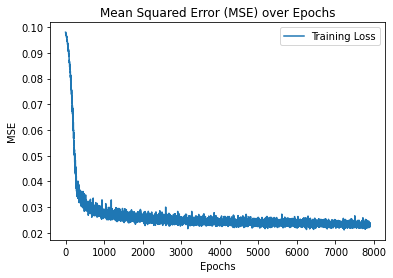

[2, 59, 40, 32, 93, 150, 14, 22, 112, 52, 117, 36, 161, 171, 92, 187, 129, 103, 161, 98, 117, 116, 165, 181, 197, 75, 66, 34, 36, 104, 188, 181, 97, 128, 78, 13, 118, 17, 89, 59, 146, 79, 95, 155, 193, 199, 111, 130, 116, 135, 179, 22, 73, 62, 7, 62, 62, 146, 185, 197, 101, 197, 125, 30, 37, 37, 108, 78, 89, 12, 41, 17, 98, 17, 12, 110, 161, 169, 42, 124, 174, 181, 37, 115, 180, 112, 1, 18, 24, 19, 117, 112, 121, 151, 79, 35, 104, 59, 169, 74]
low fidelity NN
Test MSE: 0.04614346568902227
R^2: 0.6082505289302387
Final model
Test MSE: 0.06098588712454088
R^2: 0.46124964106551425


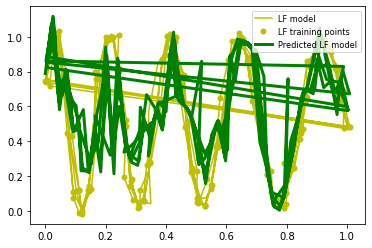

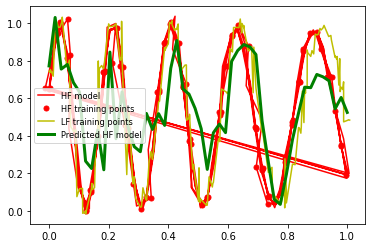

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

Saving ...
********************  # Nb. nodes = 46  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 43.6155366897583 seconds.


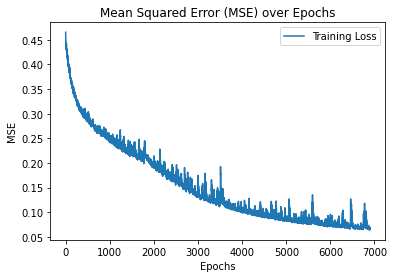

[107, 183, 88, 43, 112, 45, 102, 143, 111, 154, 62, 25, 13, 177, 49, 69, 191, 93, 102, 45, 112, 46, 176, 27, 143, 194, 124, 21, 156, 110, 90, 146, 15, 145, 10, 151, 102, 11, 191, 186, 77, 41, 86, 45, 155, 13, 112, 144, 47, 46, 156, 69, 181, 192, 9, 72, 44, 104, 4, 118, 15, 76, 76, 93, 67, 127, 194, 114, 179, 89, 76, 178, 103, 163, 27, 120, 75, 169, 116, 53, 106, 93, 116, 196, 9, 86, 89, 72, 9, 126, 119, 185, 57, 61, 19, 15, 8, 6, 162, 33]
The function training took 33.507590532302856 seconds.


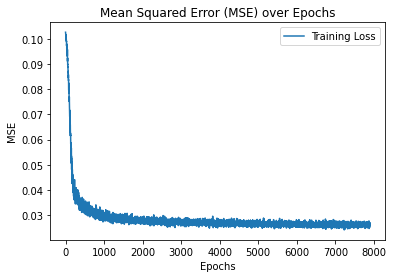

[107, 183, 88, 43, 112, 45, 102, 143, 111, 154, 62, 25, 13, 177, 49, 69, 191, 93, 102, 45, 112, 46, 176, 27, 143, 194, 124, 21, 156, 110, 90, 146, 15, 145, 10, 151, 102, 11, 191, 186, 77, 41, 86, 45, 155, 13, 112, 144, 47, 46, 156, 69, 181, 192, 9, 72, 44, 104, 4, 118, 15, 76, 76, 93, 67, 127, 194, 114, 179, 89, 76, 178, 103, 163, 27, 120, 75, 169, 116, 53, 106, 93, 116, 196, 9, 86, 89, 72, 9, 126, 119, 185, 57, 61, 19, 15, 8, 6, 162, 33]
low fidelity NN
Test MSE: 0.002147646944198358
R^2: 0.981446607229016
Final model
Test MSE: 0.013930691851446549
R^2: 0.8769360324324537


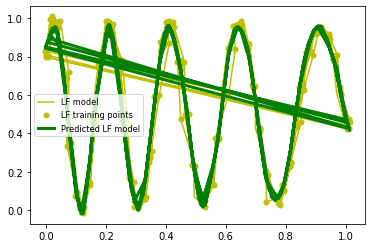

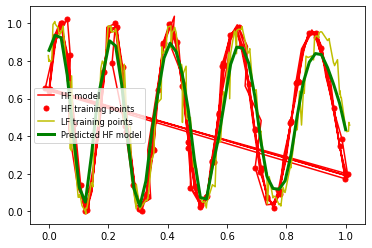

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 41.645018577575684 seconds.


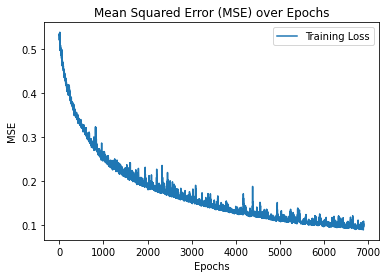

[139, 97, 120, 107, 183, 47, 50, 99, 168, 183, 141, 40, 142, 118, 163, 106, 30, 172, 39, 88, 41, 22, 99, 22, 84, 99, 56, 23, 102, 10, 137, 199, 70, 23, 122, 9, 111, 41, 170, 105, 180, 60, 4, 100, 41, 192, 27, 19, 33, 27, 40, 115, 50, 142, 12, 130, 93, 41, 158, 42, 21, 104, 116, 74, 96, 134, 177, 28, 143, 96, 175, 28, 74, 133, 37, 65, 149, 138, 79, 164, 20, 40, 61, 18, 105, 11, 78, 152, 87, 181, 23, 131, 162, 122, 83, 28, 79, 15, 128, 192]
The function training took 35.309215784072876 seconds.


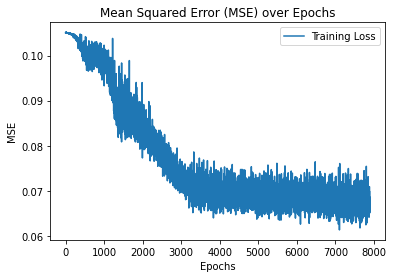

[139, 97, 120, 107, 183, 47, 50, 99, 168, 183, 141, 40, 142, 118, 163, 106, 30, 172, 39, 88, 41, 22, 99, 22, 84, 99, 56, 23, 102, 10, 137, 199, 70, 23, 122, 9, 111, 41, 170, 105, 180, 60, 4, 100, 41, 192, 27, 19, 33, 27, 40, 115, 50, 142, 12, 130, 93, 41, 158, 42, 21, 104, 116, 74, 96, 134, 177, 28, 143, 96, 175, 28, 74, 133, 37, 65, 149, 138, 79, 164, 20, 40, 61, 18, 105, 11, 78, 152, 87, 181, 23, 131, 162, 122, 83, 28, 79, 15, 128, 192]
low fidelity NN
Test MSE: 0.016175654009203625
R^2: 0.8702110348051358
Final model
Test MSE: 0.0738664031015622
R^2: 0.3474629449449754


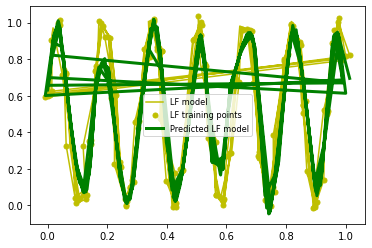

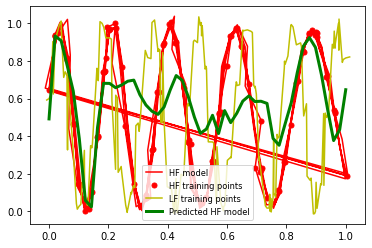

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

Saving ...
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 42.37454438209534 seconds.


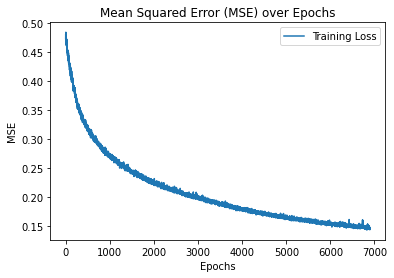

[120, 140, 69, 35, 86, 21, 149, 83, 101, 1, 59, 98, 167, 165, 118, 120, 121, 85, 60, 35, 4, 80, 87, 160, 36, 81, 58, 121, 149, 98, 188, 112, 42, 69, 171, 94, 27, 174, 193, 146, 40, 103, 173, 109, 106, 128, 193, 162, 50, 135, 36, 133, 47, 1, 44, 21, 29, 111, 84, 39, 75, 43, 140, 141, 69, 188, 180, 197, 149, 4, 164, 190, 150, 99, 199, 77, 95, 11, 93, 25, 170, 114, 178, 137, 195, 83, 195, 95, 185, 91, 9, 58, 40, 34, 6, 140, 116, 197, 133, 41]
The function training took 34.15041756629944 seconds.


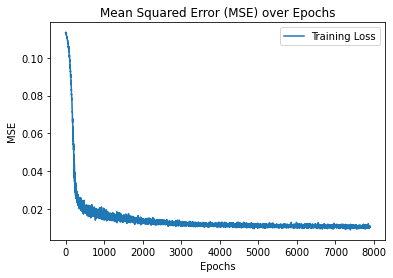

[120, 140, 69, 35, 86, 21, 149, 83, 101, 1, 59, 98, 167, 165, 118, 120, 121, 85, 60, 35, 4, 80, 87, 160, 36, 81, 58, 121, 149, 98, 188, 112, 42, 69, 171, 94, 27, 174, 193, 146, 40, 103, 173, 109, 106, 128, 193, 162, 50, 135, 36, 133, 47, 1, 44, 21, 29, 111, 84, 39, 75, 43, 140, 141, 69, 188, 180, 197, 149, 4, 164, 190, 150, 99, 199, 77, 95, 11, 93, 25, 170, 114, 178, 137, 195, 83, 195, 95, 185, 91, 9, 58, 40, 34, 6, 140, 116, 197, 133, 41]
low fidelity NN
Test MSE: 0.08858070398430719
R^2: 0.2178819802525216
Final model
Test MSE: 0.09440159168919969
R^2: 0.1660547414407071


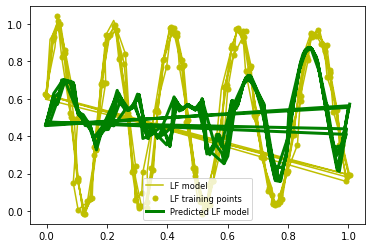

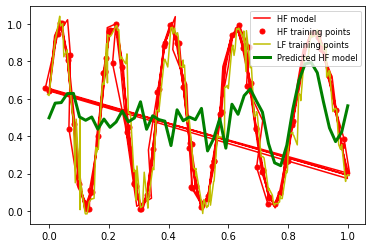

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

Saving ...
********************  # Nb. nodes = 28  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 64.42310166358948 seconds.


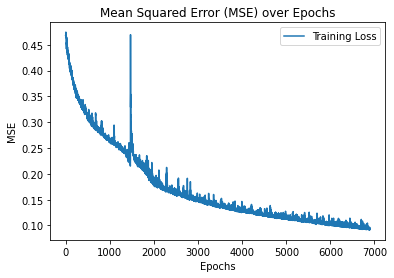

[112, 195, 13, 129, 119, 108, 19, 5, 74, 40, 25, 136, 157, 95, 72, 105, 133, 30, 143, 47, 3, 91, 5, 81, 62, 143, 81, 172, 13, 66, 125, 143, 154, 39, 153, 95, 51, 167, 32, 188, 169, 44, 191, 65, 16, 8, 160, 52, 171, 197, 10, 108, 90, 63, 91, 51, 86, 103, 131, 163, 118, 82, 11, 125, 22, 13, 27, 4, 87, 87, 188, 88, 89, 7, 40, 153, 191, 62, 118, 101, 186, 51, 31, 175, 136, 187, 184, 160, 153, 152, 129, 66, 57, 4, 23, 187, 168, 114, 166, 120]
The function training took 42.80919647216797 seconds.


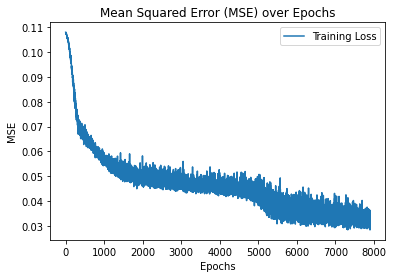

[112, 195, 13, 129, 119, 108, 19, 5, 74, 40, 25, 136, 157, 95, 72, 105, 133, 30, 143, 47, 3, 91, 5, 81, 62, 143, 81, 172, 13, 66, 125, 143, 154, 39, 153, 95, 51, 167, 32, 188, 169, 44, 191, 65, 16, 8, 160, 52, 171, 197, 10, 108, 90, 63, 91, 51, 86, 103, 131, 163, 118, 82, 11, 125, 22, 13, 27, 4, 87, 87, 188, 88, 89, 7, 40, 153, 191, 62, 118, 101, 186, 51, 31, 175, 136, 187, 184, 160, 153, 152, 129, 66, 57, 4, 23, 187, 168, 114, 166, 120]
low fidelity NN
Test MSE: 0.0035894146027977214
R^2: 0.9694717129424377
Final model
Test MSE: 0.029256698665611328
R^2: 0.7415458288710619


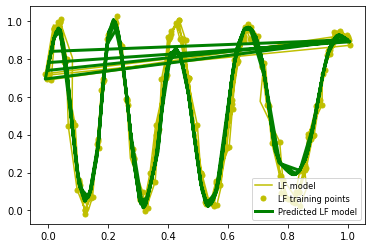

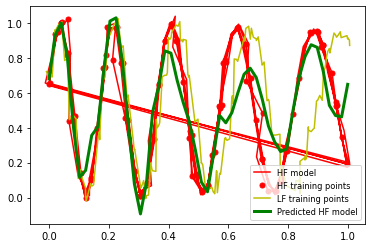

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

********************  # Nb. nodes = 28  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 42.73918604850769 seconds.


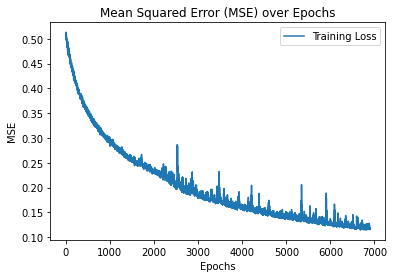

[161, 117, 99, 169, 50, 192, 149, 11, 138, 87, 73, 154, 185, 149, 167, 112, 28, 138, 34, 139, 131, 0, 150, 131, 157, 63, 112, 124, 49, 85, 199, 182, 124, 95, 191, 3, 109, 183, 3, 84, 71, 105, 126, 13, 118, 87, 82, 128, 191, 0, 102, 120, 5, 140, 78, 51, 24, 92, 146, 18, 5, 89, 88, 13, 171, 74, 138, 43, 130, 166, 118, 3, 171, 91, 43, 20, 46, 60, 38, 31, 148, 187, 87, 190, 114, 186, 66, 137, 85, 102, 102, 149, 93, 101, 181, 199, 137, 163, 85, 13]
The function training took 34.30162787437439 seconds.


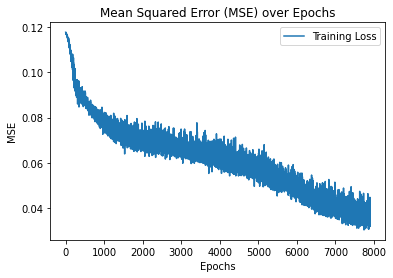

[161, 117, 99, 169, 50, 192, 149, 11, 138, 87, 73, 154, 185, 149, 167, 112, 28, 138, 34, 139, 131, 0, 150, 131, 157, 63, 112, 124, 49, 85, 199, 182, 124, 95, 191, 3, 109, 183, 3, 84, 71, 105, 126, 13, 118, 87, 82, 128, 191, 0, 102, 120, 5, 140, 78, 51, 24, 92, 146, 18, 5, 89, 88, 13, 171, 74, 138, 43, 130, 166, 118, 3, 171, 91, 43, 20, 46, 60, 38, 31, 148, 187, 87, 190, 114, 186, 66, 137, 85, 102, 102, 149, 93, 101, 181, 199, 137, 163, 85, 13]
low fidelity NN
Test MSE: 0.009092580418199185
R^2: 0.923104628970317
Final model
Test MSE: 0.03059347108392204
R^2: 0.7297367587052397


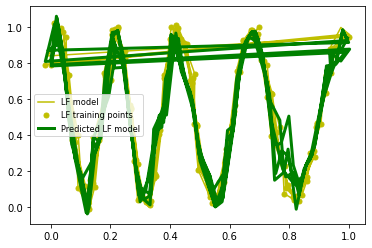

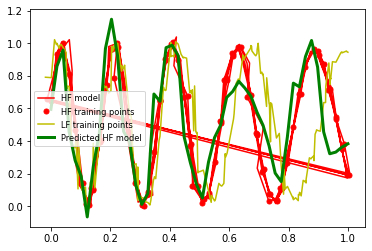

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

Saving ...
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 0  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 44.710310220718384 seconds.


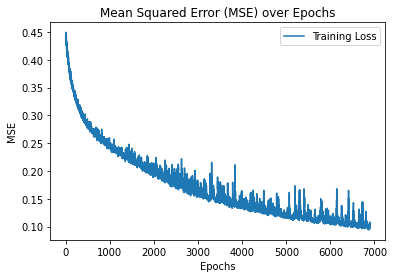

[75, 61, 25, 157, 30, 158, 176, 155, 2, 65, 19, 188, 132, 83, 134, 148, 26, 26, 77, 54, 25, 6, 66, 23, 176, 18, 4, 74, 9, 162, 44, 86, 65, 198, 149, 82, 16, 86, 2, 41, 6, 15, 51, 198, 24, 178, 68, 130, 86, 139, 173, 187, 86, 123, 85, 47, 184, 77, 189, 79, 196, 94, 66, 156, 54, 115, 25, 136, 15, 56, 25, 196, 2, 184, 141, 15, 172, 188, 161, 142, 47, 158, 107, 161, 20, 165, 163, 3, 42, 161, 14, 111, 127, 48, 178, 42, 143, 173, 42, 146]
The function training took 33.822508573532104 seconds.


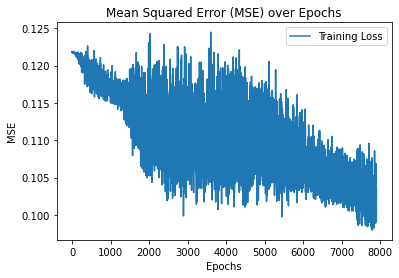

[75, 61, 25, 157, 30, 158, 176, 155, 2, 65, 19, 188, 132, 83, 134, 148, 26, 26, 77, 54, 25, 6, 66, 23, 176, 18, 4, 74, 9, 162, 44, 86, 65, 198, 149, 82, 16, 86, 2, 41, 6, 15, 51, 198, 24, 178, 68, 130, 86, 139, 173, 187, 86, 123, 85, 47, 184, 77, 189, 79, 196, 94, 66, 156, 54, 115, 25, 136, 15, 56, 25, 196, 2, 184, 141, 15, 172, 188, 161, 142, 47, 158, 107, 161, 20, 165, 163, 3, 42, 161, 14, 111, 127, 48, 178, 42, 143, 173, 42, 146]
low fidelity NN
Test MSE: 0.028066731396162024
R^2: 0.7748737444694176
Final model
Test MSE: 0.08277179345940698
R^2: 0.2687925758160832


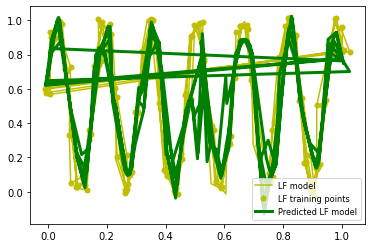

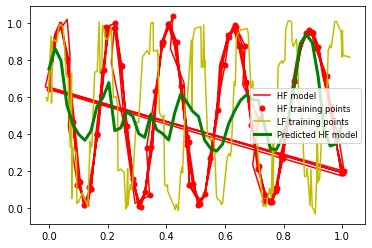

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

Saving ...
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 5  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 43.5946683883667 seconds.


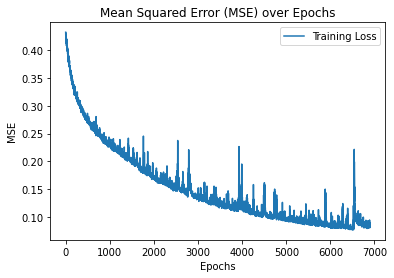

[176, 133, 132, 92, 184, 87, 71, 134, 188, 46, 59, 198, 42, 16, 71, 169, 40, 178, 166, 173, 27, 113, 110, 32, 54, 92, 7, 59, 174, 133, 8, 74, 89, 39, 190, 94, 83, 132, 123, 50, 2, 192, 70, 19, 172, 87, 199, 25, 169, 71, 34, 191, 157, 71, 195, 56, 92, 177, 71, 133, 98, 165, 111, 20, 52, 56, 48, 37, 96, 122, 100, 199, 56, 72, 106, 11, 117, 184, 33, 35, 189, 39, 75, 20, 60, 17, 125, 5, 75, 32, 46, 177, 62, 166, 58, 11, 162, 141, 160, 113]
The function training took 34.90515756607056 seconds.


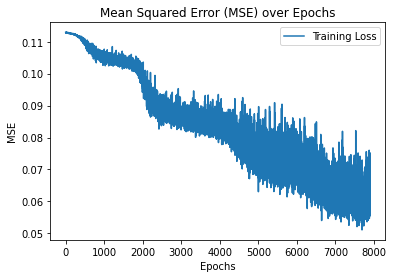

[176, 133, 132, 92, 184, 87, 71, 134, 188, 46, 59, 198, 42, 16, 71, 169, 40, 178, 166, 173, 27, 113, 110, 32, 54, 92, 7, 59, 174, 133, 8, 74, 89, 39, 190, 94, 83, 132, 123, 50, 2, 192, 70, 19, 172, 87, 199, 25, 169, 71, 34, 191, 157, 71, 195, 56, 92, 177, 71, 133, 98, 165, 111, 20, 52, 56, 48, 37, 96, 122, 100, 199, 56, 72, 106, 11, 117, 184, 33, 35, 189, 39, 75, 20, 60, 17, 125, 5, 75, 32, 46, 177, 62, 166, 58, 11, 162, 141, 160, 113]
low fidelity NN
Test MSE: 0.019457750626356657
R^2: 0.8436017493343406
Final model
Test MSE: 0.09206273308497653
R^2: 0.18671625793138347


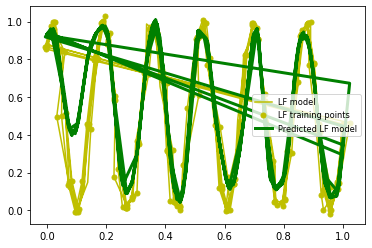

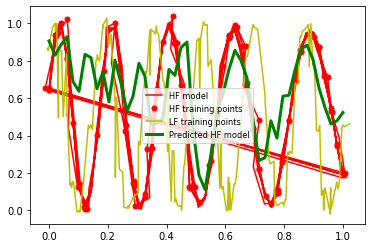

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

Saving ...
********************  # Nb. nodes = 10  ********************
********************  # Diff: = 75  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 43.516114711761475 seconds.


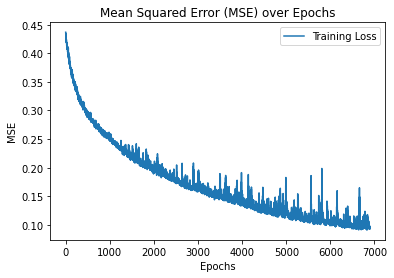

[116, 53, 174, 86, 135, 148, 100, 2, 24, 16, 133, 63, 95, 197, 59, 42, 19, 129, 177, 80, 91, 106, 110, 184, 50, 60, 171, 32, 154, 122, 188, 29, 88, 84, 135, 146, 137, 180, 51, 21, 189, 163, 94, 102, 104, 97, 131, 172, 129, 21, 74, 155, 92, 151, 11, 196, 192, 137, 84, 31, 31, 140, 22, 154, 154, 115, 24, 16, 149, 177, 127, 174, 131, 149, 160, 118, 93, 117, 27, 42, 22, 93, 184, 189, 178, 93, 132, 140, 60, 96, 180, 180, 7, 34, 73, 174, 144, 170, 140, 144]
The function training took 33.571757316589355 seconds.


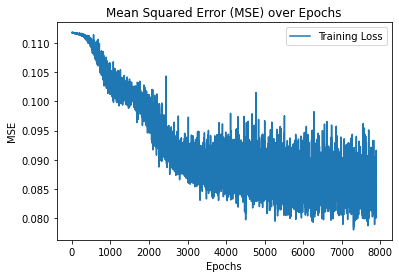

[116, 53, 174, 86, 135, 148, 100, 2, 24, 16, 133, 63, 95, 197, 59, 42, 19, 129, 177, 80, 91, 106, 110, 184, 50, 60, 171, 32, 154, 122, 188, 29, 88, 84, 135, 146, 137, 180, 51, 21, 189, 163, 94, 102, 104, 97, 131, 172, 129, 21, 74, 155, 92, 151, 11, 196, 192, 137, 84, 31, 31, 140, 22, 154, 154, 115, 24, 16, 149, 177, 127, 174, 131, 149, 160, 118, 93, 117, 27, 42, 22, 93, 184, 189, 178, 93, 132, 140, 60, 96, 180, 180, 7, 34, 73, 174, 144, 170, 140, 144]
low fidelity NN
Test MSE: 0.00884670884442667
R^2: 0.9306541633495806
Final model
Test MSE: 0.0823092503642147
R^2: 0.27287868934672066


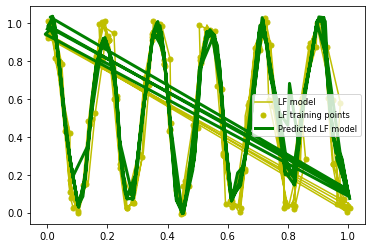

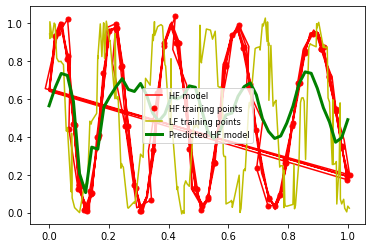

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

********************  # Nb. nodes = 10  ********************
********************  # Diff: = 1  ********************
********************  # NHF: = 100  ********************
********************  # NLF: = 200  ********************
The function training took 42.210967779159546 seconds.


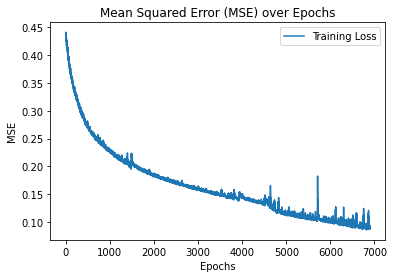

[65, 147, 80, 86, 181, 99, 177, 29, 166, 112, 73, 21, 197, 7, 142, 122, 141, 75, 162, 197, 16, 169, 74, 40, 198, 1, 122, 30, 60, 114, 111, 179, 158, 164, 175, 118, 141, 82, 123, 192, 62, 92, 89, 165, 14, 34, 29, 82, 32, 117, 58, 173, 18, 115, 132, 125, 18, 175, 30, 54, 107, 138, 157, 9, 94, 103, 159, 118, 90, 109, 62, 92, 136, 59, 131, 166, 116, 109, 90, 12, 18, 39, 9, 176, 117, 188, 86, 127, 130, 36, 165, 88, 184, 193, 17, 163, 75, 175, 74, 132]
The function training took 35.94420027732849 seconds.


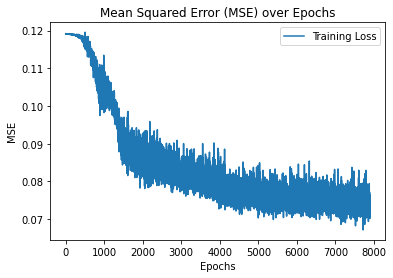

[65, 147, 80, 86, 181, 99, 177, 29, 166, 112, 73, 21, 197, 7, 142, 122, 141, 75, 162, 197, 16, 169, 74, 40, 198, 1, 122, 30, 60, 114, 111, 179, 158, 164, 175, 118, 141, 82, 123, 192, 62, 92, 89, 165, 14, 34, 29, 82, 32, 117, 58, 173, 18, 115, 132, 125, 18, 175, 30, 54, 107, 138, 157, 9, 94, 103, 159, 118, 90, 109, 62, 92, 136, 59, 131, 166, 116, 109, 90, 12, 18, 39, 9, 176, 117, 188, 86, 127, 130, 36, 165, 88, 184, 193, 17, 163, 75, 175, 74, 132]
low fidelity NN
Test MSE: 0.013736629084715386
R^2: 0.8869351960705684
Final model
Test MSE: 0.0678803648682469
R^2: 0.40034370800099783


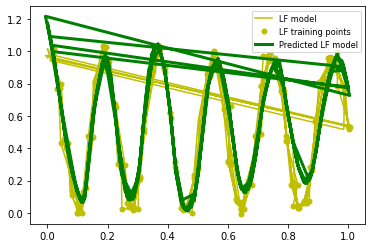

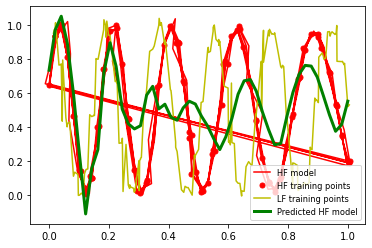

    Discretization  diffusion       R2
0             46.0        0.0  0.21620
1             46.0        5.0  0.83334
2             46.0       75.0  0.46125
3             46.0        1.0  0.87694
4             28.0        0.0  0.34746
5             28.0        5.0  0.16605
6             28.0       75.0  0.74155
7             28.0        1.0  0.72974
8             10.0        0.0  0.26879
9             10.0        5.0  0.18672
10            10.0       75.0  0.27288
11            10.0        1.0  0.40034
    Discretization  diffusion      MSE
0             46.0        0.0  0.08872
1             46.0        5.0  0.01887
2             46.0       75.0  0.06099
3             46.0        1.0  0.01393
4             28.0        0.0  0.07387
5             28.0        5.0  0.09440
6             28.0       75.0  0.02926
7             28.0        1.0  0.03059
8             10.0        0.0  0.08277
9             10.0        5.0  0.09206
10            10.0       75.0  0.08231
11            10.0       

C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:169: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_LF_df = r2_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:171: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  r2_HF_df = r2_HF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:173: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_LF_df = mse_LF_df.append(new, ignore_index=True)
C:\Users\Giacomo\AppData\Local\Temp\ipykernel_12924\2083904392.py:175: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  mse_HF_df = mse_HF_df

In [10]:
               
for m in range(len(Discretizations)):
    test_mse_HF_list = []
    test_mse_LF_list = []

    r2_HF_list = []
    r2_LF_list = []
    for d in range(len(diffusion)):
        for nhf in n_HF:
            for nlf in Nlf:
        
                print(
                f"********************  # Nb. nodes = {Discretizations[m]}  ********************"
                )
                
                print(
                f"********************  # Diff: = {diffusion[d]}  ********************"
                )
                
                print(
                f"********************  # NHF: = {nhf}  ********************"
                )
                print(
                f"********************  # NLF: = {nlf}  ********************"
                )
                ### import of the Low Fidelity component of the dataset 
                file_path_LF = "../DATA/reaction_diffusion_LF_"+str(Discretizations[m])+"_d"+str(diffusion[d])+".mat"
                (reaction_LF_test, U_LF_test) = import_data(file_path_LF)

                # selection and normalization of the dataset
                U_LF_test = U_LF_test[
                :,
                - 1,
                int(4*(Discretizations[m]-1)/9),
                int(4*(Discretizations[m]-1)/9)
                ]        
                U_LF_test = normalization(U_LF_test)
                reaction_LF_test = normalization(reaction_LF_test)
                
                # transformation of the Low fidelity test set
                reaction_LF_test_original=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                U_LF_test_original=U_LF_test
                
                # dataset augmentation adding a noise
                noise_std1=[0.02,0.01,0.02,0.01]
                noise_std2=[0.01,0.005,0.01,0.005]
                (U_LF_test,reaction_LF_test)=add_noise(noise_std1,noise_std2,reaction_LF_test,U_LF_test)
                
                # randomization and selection of the training set
                permutation = np.random.permutation(len(reaction_HF_test))
                reaction_HF = reaction_HF_test[permutation,:][0:nhf,:]
                U_HF = U_HF_test[permutation][0:nhf]
                permutation = np.random.permutation(len(reaction_LF_test))
                reaction_LF = reaction_LF_test[permutation][0:nlf]
                U_train_LF = U_LF_test[permutation][0:nlf]

                # transformation of the dataset
                reaction_LF=np.c_[reaction_LF, np.abs(np.sin(5*np.pi*reaction_LF[:, 0]-5*np.pi/6))]
                reaction_LF_test=np.c_[reaction_LF_test, np.abs(np.sin(5*np.pi*reaction_LF_test[:, 0]-5*np.pi/6))]
                
                ##########################      Neural Network     ##########################
                K.clear_session()
                
                # parameters 
                bestLF_params = {
                    "lr": 0.0255,
                    "kernel_init": "glorot_uniform",
                    "opt": "Adam",
                } 
                best_params={'kernel_init': 'uniform', 'l2weight': 0.005395541657336886, 'lr': 0.0025412188591473228, 'nodes': 12.0, 'opt': 'Adamax'}

                # reproducibilty porpuse 
                learning_rate = bestLF_params["lr"]
                optimizer_type = bestLF_params["opt"]

                # Fissa i parametri di ottimizzazione
                if optimizer_type == "Adam":
                    optimizer = Adam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Nadam":
                    optimizer = Nadam(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                elif optimizer_type == "Adamax":
                    optimizer = Adamax(learning_rate=learning_rate, beta_1=0.9, beta_2=0.999, epsilon=1e-7)
                else:
                    raise ValueError(f"Optimizer type '{optimizer_type}' not recognized.")
                
                
                # Multifidelity network 
                names=["LF","2step"]
                params=[bestLF_params, best_params]
                model= MultiFidelity(names,params=params,data_train_LF=reaction_LF,output_train_LF=U_train_LF,data_train_HF=reaction_HF, output_train_HF=U_HF,N=Nepo,n=batch_size,do_HPO=False,verbose=False)
  
                # low fidelity part of the network 
                ULF = model.model_list[0].prediction(reaction_LF_test_original)
                print("low fidelity NN")
                
                (test_mse_LF,r2_LF) = model.model_list[0].performance(reaction_LF_test_original,U_LF_test_original)
                test_mse_LF_list.append(test_mse_LF)
                r2_LF_list.append(r2_LF)

                # creation of the input of the second part of the 2 steps NN to study the high fidelity model
                input_HF = np.concatenate(
                    (reaction_HF_test_original,  model.model_list[0].prediction(reaction_HF_test_original).reshape(-1,1)),axis=1
                )  # <- TRAINING INPUT for the second NN: NN_HF

                input_HF_train = np.concatenate(
                    (reaction_HF,  model.model_list[0].prediction(reaction_HF).reshape(-1,1)),axis=1
                ) 
                # performance of the last part of the network
                print("Final model")
                (test_mse_HF,r2_HF) = model.model_list[1].performance(input_HF,U_HF_test_original)                
                test_mse_HF_list.append(test_mse_HF)
                r2_HF_list.append(r2_HF)
                
                
                # plots of the model
                plt.figure()
                plt.plot(
                reaction_LF_test[:, 0], U_LF_test, "y-", linewidth=1.5, label="LF model"
                )
                plt.plot(
                reaction_LF[:, 0],
                U_train_LF,
                "yo",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                reaction_LF_test[:, 0],
                model.model_list[0].prediction(reaction_LF_test),
                "g-",
                linewidth=3,
                label="Predicted LF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()
                
                plt.figure()
                plt.plot(
                reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model"
                )
                plt.plot(
                input_HF_train[:, 0],
                U_HF,
                "ro",
                markersize=5,
                label="HF training points",
                )
                
                
                order=np.argsort(reaction_LF[:,0])
                
                plt.plot(
                reaction_LF[order,0],
                U_train_LF[order],
                "y-",
                markersize=5,
                label="LF training points",
                )
                plt.plot(
                input_HF[:, 0],
                model.model_list[1].prediction(input_HF),
                "g-",
                linewidth=3,
                label="Predicted HF model",
                )
                plt.legend(prop={"size": 8.3})
                plt.show()
                
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_LF_list[-1]}
                r2_LF_df = r2_LF_df.append(new, ignore_index=True)      
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'R2': r2_HF_list[-1]}
                r2_HF_df = r2_HF_df.append(new, ignore_index=True)  
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_LF_list[-1]}
                mse_LF_df = mse_LF_df.append(new, ignore_index=True) 
                new = {'Discretization': Discretizations[m], 'diffusion': diffusion[d], 'MSE': test_mse_HF_list[-1]}
                mse_HF_df = mse_HF_df.append(new, ignore_index=True)
            
                # save the model
                if not r2_HF_list[:-1]:
                    model.save(str(Discretizations[m]))
                elif r2_HF_list[:-1] and r2_HF_list[-1] < max(r2_HF_list[:-1]):
                    model.save(str(Discretizations[m]))

        
print(r2_HF_df.round(5))
print(mse_HF_df.round(5))

## Save the output

In [11]:
os.makedirs("MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class")

r2_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/r2_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_HF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/mse_HF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
r2_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
mse_LF_df.to_csv(
    "./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/mse_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/U_HF_list.data", "wb") as filehandle:
    # store the data as binary data stream
    pickle.dump(U_HF_list, filehandle)

with open("./MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class/U_LF_list.data", "wb") as filehandle:
    pickle.dump(U_LF_list, filehandle)

FileExistsError: [WinError 183] Impossibile creare un file, se il file esiste già: 'MF_LF_200_7000_HF_100_8000_2NN_noise_fourier_class'